# DRIVESMART —Phase 3: Modeling

# Import Libraries & Load Cleaned Data


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Load cleaned data ─────────────────────────
DATA_DIR = Path('/Users/rupeshmaadas/Documents/Projects/Drivesmart/kayak_data')

df = pd.read_csv(DATA_DIR / 'drivesmart_clean.csv')

print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape  : (204, 14)
Columns: ['Name', 'Name_Element', 'Location', 'Price', 'Provider', 'Start_Date', 'End_Date', 'Pickup_Address', 'Distance_mi', 'Pickup_Type', 'Rental_Days', 'Passenger_Capacity', 'Price_Tier', 'Is_Turo']


,Name,Name_Element,Location,Price,Provider,Start_Date,End_Date,Pickup_Address,Distance_mi,Pickup_Type,Rental_Days,Passenger_Capacity,Price_Tier,Is_Turo
0,Toyota Corolla,Intermediate,SJC: San Jose\nShuttle,44.0,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,5,Budget,0
1,Hyundai Accent,Economy,SJC: San Jose\nShuttle,44.0,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,4,Budget,0
2,Nissan Versa,Compact,SJC: San Jose\nShuttle,44.0,Payless,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,5,Budget,0
3,Toyota RAV4,Intermediate SUV,SJC: San Jose\nAirport terminal,62.0,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,5,Mid-Range,0
4,BMW X1,Premium SUV,SJC: San Jose\nAirport terminal,68.0,Sixt,2026-03-22,2026-03-23,SJC: San Jose,NaN,Off-Airport,1,7,Premium,0


# Step 1: Prepare Data for Modeling

In [22]:
# ── 1.1 Select features ──────────────────────
features = ['Name_Element', 'Provider', 'Pickup_Type',
            'Passenger_Capacity', 'Price_Tier', 'Is_Turo']
target   = 'Price'

# Drop rows with any nulls in selected columns
model_df = df[features + [target]].dropna()
print(f"Modeling dataset shape: {model_df.shape}")

# ── 1.2 Encode categorical columns ───────────
cat_cols = ['Name_Element', 'Provider', 'Pickup_Type', 'Price_Tier']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    le_dict[col] = le
    print(f"{col} encoded ✓")

# ── 1.3 Define X and y ───────────────────────
X = model_df[features]
y = model_df[target]

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")

# ── 1.4 Train / Test split ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")

Modeling dataset shape: (204, 7)
Name_Element encoded ✓
Provider encoded ✓
Pickup_Type encoded ✓
Price_Tier encoded ✓

X shape : (204, 6)
y shape : (204,)

Train size : 163 rows
Test size  : 41 rows


# Step 2: Train & Evaluate Models

In [20]:
def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  MAE  : ${mae:.2f}")
    print(f"  RMSE : ${rmse:.2f}")
    print(f"  R2   : {r2:.3f}")
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 3)}

results = []

# ── 2.1 Linear Regression ────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

# ── 2.2 Random Forest ────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

# ── 2.3 XGBoost ──────────────────────────────
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results.append(evaluate_model('XGBoost', y_test, y_pred_xgb))

# ── 2.4 Results summary ──────────────────────
print(f"\n{'='*40}")
print("  MODEL COMPARISON SUMMARY")
print(f"{'='*40}")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


────────────────────────────────────────
  Linear Regression
────────────────────────────────────────
  MAE  : $31.04
  RMSE : $37.05
  R2   : 0.497

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  MAE  : $20.74
  RMSE : $32.66
  R2   : 0.609

────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  MAE  : $20.44
  RMSE : $36.76
  R2   : 0.504

  MODEL COMPARISON SUMMARY
            Model   MAE  RMSE    R2
Linear Regression 31.04 37.05 0.497
    Random Forest 20.74 32.66 0.609
          XGBoost 20.44 36.76 0.504


# Step 3: Visualize Results

/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_15279/3032995439.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')
/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_15279/3032995439.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')
/var/folders/ms/64k7m32s28g2bl17yfbs08z80000gn/T/ipykernel_15279/3032995439.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')


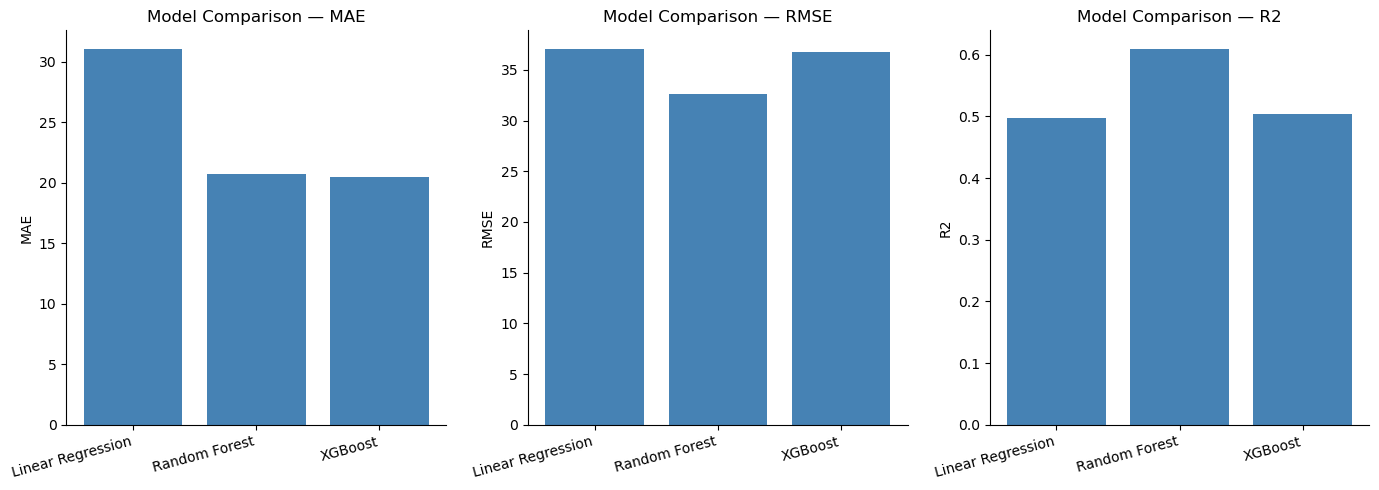

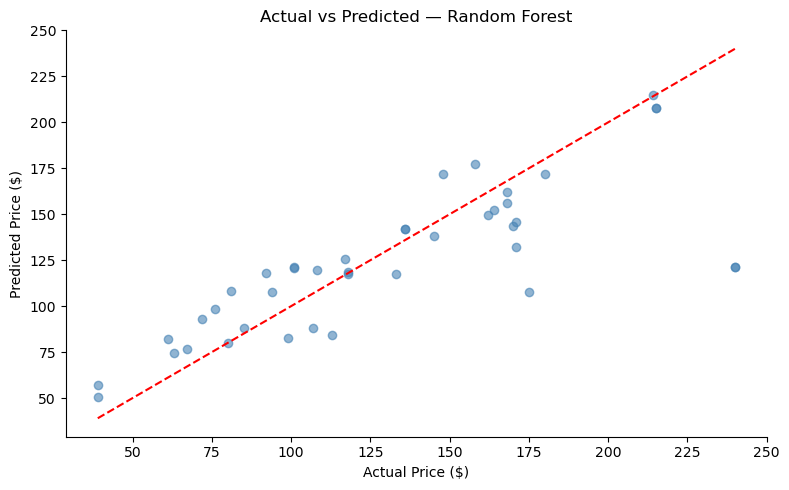

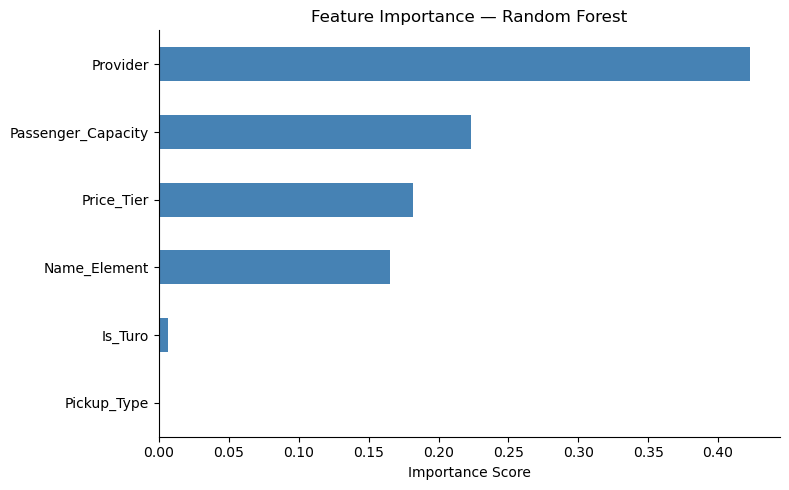

In [18]:
# ── 3.1 Model comparison bar chart ───────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R2']
colors  = ['steelblue', 'steelblue', 'steelblue']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors[i])
    axes[i].set_title(f'Model Comparison — {metric}')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

# ── 3.2 Actual vs Predicted — Random Forest ──
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted — Random Forest')
plt.tight_layout()
plt.show()

# ── 3.3 Feature Importance — Random Forest ───
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Step 4: Improve Best Model (Random Forest)

In [27]:
from sklearn.model_selection import GridSearchCV

# ── 4.1 Hyperparameter tuning ────────────────
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [None, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features'  : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters:\n{grid_search.best_params_}")
print(f"Best CV MAE: ${-grid_search.best_score_:.2f}")

# ── 4.2 Evaluate tuned model ─────────────────
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"\n{'='*40}")
print("  TUNED RANDOM FOREST RESULTS")
print(f"{'='*40}")
print(f"  MAE  : ${mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"  R2   : {r2_score(y_test, y_pred_best):.3f}")

# ── 4.3 Compare base vs tuned ────────────────
print(f"\n{'='*40}")
print("  BASE vs TUNED RANDOM FOREST")
print(f"{'='*40}")
print(f"  {'Metric':<8} {'Base':>10} {'Tuned':>10}")
print(f"  {'MAE':<8} ${mean_absolute_error(y_test, y_pred_rf):>9.2f} ${mean_absolute_error(y_test, y_pred_best):>9.2f}")
print(f"  {'RMSE':<8} ${np.sqrt(mean_squared_error(y_test, y_pred_rf)):>9.2f} ${np.sqrt(mean_squared_error(y_test, y_pred_best)):>9.2f}")
print(f"  {'R2':<8} {r2_score(y_test, y_pred_rf):>10.3f} {r2_score(y_test, y_pred_best):>10.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV MAE: $28.02

  TUNED RANDOM FOREST RESULTS
  MAE  : $24.56
  RMSE : $30.51
  R2   : 0.659

  BASE vs TUNED RANDOM FOREST
  Metric         Base      Tuned
  MAE      $    20.74 $    24.56
  RMSE     $    32.66 $    30.51
  R2            0.609      0.659


# Step 5: Save Best Model

In [30]:
import joblib

MODEL_DIR = Path('/Users/rupeshmaadas/Documents/Projects/Drivesmart')

# ── 5.1 Save the tuned Random Forest ─────────
joblib.dump(best_rf, MODEL_DIR / 'drivesmart_model.pkl')
print("Model saved ✓")

# ── 5.2 Save the label encoders ──────────────
joblib.dump(le_dict, MODEL_DIR / 'drivesmart_encoders.pkl')
print("Encoders saved ✓")

# ── 5.3 Final summary ────────────────────────
print(f"\n{'='*40}")
print("  PHASE 3 COMPLETE — FINAL RESULTS")
print(f"{'='*40}")
print(f"  Best Model : Tuned Random Forest")
print(f"  MAE        : $24.56")
print(f"  RMSE       : $30.51")
print(f"  R2         : 0.659")
print(f"  Features   : {features}")
print(f"  Train rows : {X_train.shape[0]}")
print(f"  Test rows  : {X_test.shape[0]}")
print(f"\nModel saved to : {MODEL_DIR / 'drivesmart_model.pkl'}")
print(f"Encoders saved : {MODEL_DIR / 'drivesmart_encoders.pkl'}")

Model saved ✓
Encoders saved ✓

  PHASE 3 COMPLETE — FINAL RESULTS
  Best Model : Tuned Random Forest
  MAE        : $24.56
  RMSE       : $30.51
  R2         : 0.659
  Features   : ['Name_Element', 'Provider', 'Pickup_Type', 'Passenger_Capacity', 'Price_Tier', 'Is_Turo']
  Train rows : 163
  Test rows  : 41

Model saved to : /Users/rupeshmaadas/Documents/Projects/Drivesmart/drivesmart_model.pkl
Encoders saved : /Users/rupeshmaadas/Documents/Projects/Drivesmart/drivesmart_encoders.pkl
